# ExioNAICS Emissions Estimation\n\nLoading and exploring the ExioNAICS dataset linking company NAICS codes to ExioML emissions data.

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv('ExioNAICS.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (20535, 29)

Columns:
['Company Name', 'Company Description', 'NAICS Code', 'NAICS Title', '2022 NAICS Code', '2022 NAICS Title', '2017 NAICS Code', '2017 NAICS Title', 'Description', 'NAICS_5 Code', 'NAICS_5 Title', 'NAICS_5 Description', 'NAICS_4 Code', 'NAICS_4 Title', 'NAICS_4 Description', 'NAICS_3 Code', 'NAICS_3 Title', 'NAICS_3 Description', 'NAICS_2 Code', 'NAICS_2 Title', 'NAICS_2 Description', 'ExioML', 'region', 'Value Added [M.EUR]', 'Employment [1000 p.]', 'GHG emissions [kg CO2 eq.]', 'Energy Carrier Net Total [TJ]', 'Year', 'Carbon Intensity']


,Company Name,Company Description,NAICS Code,NAICS Title,2022 NAICS Code,2022 NAICS Title,2017 NAICS Code,2017 NAICS Title,Description,NAICS_5 Code,...,NAICS_2 Title,NAICS_2 Description,ExioML,region,Value Added [M.EUR],Employment [1000 p.],GHG emissions [kg CO2 eq.],Energy Carrier Net Total [TJ],Year,Carbon Intensity
0,Foot Locker Specialty Inc,Foot Locker Inc (Foot Locker) is a specialty r...,448150,Clothing Accessories Stores,458110,Clothing and Clothing Accessories Retailers,448150,Clothing Accessories Stores,This industry comprises establishments primari...,45811,...,Retail Trade,The Sector as a Whole\n\nThe Retail Trade sect...,"Retail trade services, except of motor vehicl...",US,155839.081079,26252.194517,1.974719e+08,3603.462783,2022,0.001267
1,Cengage Learning Inc,Cengage is the education and technology compan...,511130,Book Publishers,513130,Book Publishers,511130,Book Publishers,This industry comprises establishments known a...,51313,...,Information,The Sector as a Whole\n\nThe Information secto...,Printed matter and recorded media (22),US,101252.173354,359.127253,8.762522e+09,269198.419669,2022,0.086542
2,Cardinal Scale Mfg Co,Cardinal Scale Manufacturing Company manufactu...,333997,Scale and Balance Manufacturing,333998,All Other Miscellaneous General Purpose Machin...,333997,Scale and Balance Manufacturing,This U.S. industry comprises establishments pr...,33399,...,Manufacturing,The Sector as a Whole\n\nThe Manufacturing sec...,"Medical, precision and optical instruments, wa...",US,163416.090875,242.560449,6.744317e+09,172060.328352,2022,0.041271
3,Alticor Inc,Alticor Inc. owns and manages manufacturing an...,454390,Other Direct Selling Establishments,441330,Automotive Parts and Accessories Retailers,454390,Other Direct Selling Establishments,This industry comprises establishments primari...,44133,...,Retail Trade,The Sector as a Whole\n\nThe Retail Trade sect...,"Retail trade services, except of motor vehicl...",US,155839.081079,26252.194517,1.974719e+08,3603.462783,2022,0.001267
4,S Butler-Rosboro Corporation,Rosboro is North America's largest producer of...,335110,Electric Lamp Bulb and Part Manufacturing,335139,Electric Lamp Bulb and Other Lighting Equipmen...,335110,Electric Lamp Bulb and Part Manufacturing,This U.S. industry comprises establishments pr...,33513,...,Manufacturing,The Sector as a Whole\n\nThe Manufacturing sec...,Electrical machinery and apparatus n.e.c. (31),US,68675.538658,809.436143,3.051654e+09,101481.364669,2022,0.044436


In [21]:

df4 = df.iloc[: 5 , 9:20]
df4['Company Description'] = df['Company Description']
df4.head()

,NAICS_5 Code,NAICS_5 Title,NAICS_5 Description,NAICS_4 Code,NAICS_4 Title,NAICS_4 Description,NAICS_3 Code,NAICS_3 Title,NAICS_3 Description,NAICS_2 Code,NAICS_2 Title,Company Description
0,45811,Clothing and Clothing Accessories Retailers,This industry comprises establishments primari...,4581,Clothing and Clothing Accessories Retailers,This industry group comprises establishments p...,458,"Clothing, Clothing Accessories, Shoe, and Jewe...","Industries in the Clothing, Clothing Accessori...",45,Retail Trade,Foot Locker Inc (Foot Locker) is a specialty r...
1,51313,Book Publishers,This industry comprises establishments known a...,5131,"Newspaper, Periodical, Book, and Directory Pub...",This industry group comprises establishments p...,513,Publishing Industries,Industries in the Publishing Industries subsec...,51,Information,Cengage is the education and technology compan...
2,33399,All Other General Purpose Machinery Manufacturing,This industry comprises establishments primari...,3339,Other General Purpose Machinery Manufacturing,This industry group comprises establishments p...,333,Machinery Manufacturing,Industries in the Machinery Manufacturing subs...,33,Manufacturing,Cardinal Scale Manufacturing Company manufactu...
3,44133,Automotive Parts and Accessories Retailers,This industry comprises establishments primari...,4413,"Automotive Parts, Accessories, and Tire Retailers",This industry group comprises establishments p...,441,Motor Vehicle and Parts Dealers,Industries in the Motor Vehicle and Parts Deal...,44,Retail Trade,Alticor Inc. owns and manages manufacturing an...
4,33513,Electric Lighting Equipment Manufacturing,This industry comprises establishments primari...,3351,Electric Lighting Equipment Manufacturing,This industry group comprises establishments p...,335,"Electrical Equipment, Appliance, and Component...","Industries in the Electrical Equipment, Applia...",33,Manufacturing,Rosboro is North America's largest producer of...


In [5]:
df.dtypes

Company Name                      object
Company Description               object
NAICS Code                         int64
NAICS Title                       object
2022 NAICS Code                    int64
2022 NAICS Title                  object
2017 NAICS Code                    int64
2017 NAICS Title                  object
Description                       object
NAICS_5 Code                       int64
NAICS_5 Title                     object
NAICS_5 Description               object
NAICS_4 Code                       int64
NAICS_4 Title                     object
NAICS_4 Description               object
NAICS_3 Code                       int64
NAICS_3 Title                     object
NAICS_3 Description               object
NAICS_2 Code                       int64
NAICS_2 Title                     object
NAICS_2 Description               object
ExioML                            object
region                            object
Value Added [M.EUR]              float64
Employment [1000

In [6]:
df[['GHG emissions [kg CO2 eq.]', 'Energy Carrier Net Total [TJ]', 'Value Added [M.EUR]', 'Carbon Intensity']].describe()

,GHG emissions [kg CO2 eq.],Energy Carrier Net Total [TJ],Value Added [M.EUR],Carbon Intensity
count,2.053500e+04,2.053500e+04,2.053500e+04,20535.000000
mean,2.015215e+10,5.940001e+05,5.072454e+05,1.045377
std,4.089554e+10,8.295536e+05,6.669893e+05,11.388547
min,4.000249e+07,3.993563e+02,1.159420e+01,0.000829
25%,4.692428e+09,1.132304e+05,8.957599e+04,0.011579
50%,8.762522e+09,2.559767e+05,1.742608e+05,0.040340
75%,2.289523e+10,7.982216e+05,8.103529e+05,0.220712
max,1.217165e+12,9.534165e+06,2.773712e+06,262.462607


In [7]:
df.duplicated().sum()

np.int64(214)

In [8]:
df.columns

Index(['Company Name', 'Company Description', 'NAICS Code', 'NAICS Title',
       '2022 NAICS Code', '2022 NAICS Title', '2017 NAICS Code',
       '2017 NAICS Title', 'Description', 'NAICS_5 Code', 'NAICS_5 Title',
       'NAICS_5 Description', 'NAICS_4 Code', 'NAICS_4 Title',
       'NAICS_4 Description', 'NAICS_3 Code', 'NAICS_3 Title',
       'NAICS_3 Description', 'NAICS_2 Code', 'NAICS_2 Title',
       'NAICS_2 Description', 'ExioML', 'region', 'Value Added [M.EUR]',
       'Employment [1000 p.]', 'GHG emissions [kg CO2 eq.]',
       'Energy Carrier Net Total [TJ]', 'Year', 'Carbon Intensity'],
      dtype='object')

In [9]:
dup = df[df.duplicated(keep = False)] 
dup = dup.sort_values(by = list(df.columns)) 
dup = dup.reset_index(drop = True)
dup   

,Company Name,Company Description,NAICS Code,NAICS Title,2022 NAICS Code,2022 NAICS Title,2017 NAICS Code,2017 NAICS Title,Description,NAICS_5 Code,...,NAICS_2 Title,NAICS_2 Description,ExioML,region,Value Added [M.EUR],Employment [1000 p.],GHG emissions [kg CO2 eq.],Energy Carrier Net Total [TJ],Year,Carbon Intensity
0,1-800-Flowerscom Inc,"1-800-Flowers.com, Inc. is a floral and foods ...",459310,Florists,459310,Florists,453110,Florists,This industry comprises establishments general...,45931,...,Retail Trade,The Sector as a Whole\n\nThe Retail Trade sect...,"Retail trade services, except of motor vehicl...",US,155839.081079,26252.194517,1.974719e+08,3.603463e+03,2022,0.001267
1,1-800-Flowerscom Inc,"1-800-Flowers.com, Inc. is a floral and foods ...",459310,Florists,459310,Florists,453110,Florists,This industry comprises establishments general...,45931,...,Retail Trade,The Sector as a Whole\n\nThe Retail Trade sect...,"Retail trade services, except of motor vehicl...",US,155839.081079,26252.194517,1.974719e+08,3.603463e+03,2022,0.001267
2,Abercrombie & Fitch Co,AbercrombieAbercrombieA&F Co. continues its gl...,458110,Clothing and Clothing Accessories Retailers,458110,Clothing and Clothing Accessories Retailers,448110,Men's Clothing Stores,This industry comprises establishments primari...,45811,...,Retail Trade,The Sector as a Whole\n\nThe Retail Trade sect...,"Retail trade services, except of motor vehicl...",US,155839.081079,26252.194517,1.974719e+08,3.603463e+03,2022,0.001267
3,Abercrombie & Fitch Co,AbercrombieAbercrombieA&F Co. continues its gl...,458110,Clothing and Clothing Accessories Retailers,458110,Clothing and Clothing Accessories Retailers,448110,Men's Clothing Stores,This industry comprises establishments primari...,45811,...,Retail Trade,The Sector as a Whole\n\nThe Retail Trade sect...,"Retail trade services, except of motor vehicl...",US,155839.081079,26252.194517,1.974719e+08,3.603463e+03,2022,0.001267
4,Active Minerals Intl LLC,Active Minerals International LLC (AMI) is a g...,212323,Kaolin,212323,"Kaolin, Clay, and Ceramic and Refractory Miner...",212324,Kaolin and Ball Clay Mining,This U.S. industry comprises (1) establishment...,21232,...,"Mining, Quarrying, and Oil and Gas Extraction","The Sector as a Whole\n\nThe Mining, Quarrying...",Sand and clay,US,11524.459385,9.590742,1.375025e+10,9.205835e+04,2022,1.193137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,Wolverine World Wide Inc,Wolverine World Wide Inc: Overview The company...,316210,Footwear Manufacturing,316210,Footwear Manufacturing,316210,Footwear Manufacturing,This industry comprises establishments primari...,31621,...,Manufacturing,The Sector as a Whole\n\nThe Manufacturing sec...,Leather and leather products (19),US,3576.063155,52.410066,1.170350e+09,2.462725e+04,2022,0.327273
423,Worthington Industries Inc,Worthington Enterprises Inc (Worthington) form...,331221,Rolled Steel Shape Manufacturing,331221,Rolled Steel Shape Manufacturing,331221,Rolled Steel Shape Manufacturing,This U.S. industry comprises establishments pr...,33122,...,Manufacturing,The Sector as a Whole\n\nThe Manufacturing sec...,Basic iron and steel and of ferro-alloys and f...,US,18774.024963,196.072149,1.376672e+10,2.589409e+05,2022,0.733285
424,Worthington Industries Inc,Worthington Enterprises Inc (Worthington) form...,331221,Rolled Steel Shape Manufacturing,331221,Rolled Steel Shape Manufacturing,331221,Rolled Steel Shape Manufacturing,This U.S. industry comprises establishments pr...,33122,...,Manufacturing,The Sector as a Whole\n\nThe Manufacturing sec...,Basic iron and steel and of ferro-alloys and f...,US,18774.024963,196.072149,1.376672e+10,2.589409e+05,2022,0.733285
425,Zephyr Manufacturing Company,A manufacturer that continually takes pride in...,339994,Broom,339994,"Broom, Brush, and Mop Manufacturing",339994,"Broom, Brush, and Mop Manufacturing",This U.S. industry comprises establishments pr...,33999,...,Manufacturin

In [10]:
df = df.drop_duplicates() 

In [11]:
input = df[['Company Name', 'Description' , 'NAICS Code']] 
input.head() 

,Company Name,Description,NAICS Code
0,Foot Locker Specialty Inc,This industry comprises establishments primari...,448150
1,Cengage Learning Inc,This industry comprises establishments known a...,511130
2,Cardinal Scale Mfg Co,This U.S. industry comprises establishments pr...,333997
3,Alticor Inc,This industry comprises establishments primari...,454390
4,S Butler-Rosboro Corporation,This U.S. industry comprises establishments pr...,335110


=> Need cleaning in both descriptions for non-alphabetical characters like \n

In [12]:
descriptions = list(input['Description']) 
descriptions

['This industry comprises establishments primarily engaged in retailing general or specialized lines of new clothing and clothing accessories, such as hats and caps, costume jewelry, gloves, handbags, ties, wigs, toupees, and belts.  These establishments may provide basic alterations, such as hemming, taking in or letting out seams, or lengthening or shortening sleeves.\n\nCross-References. Establishments primarily engaged in--',
 'This industry comprises establishments known as book publishers.  Establishments in this industry carry out design, editing, and marketing activities necessary for producing and distributing books.  These establishments may publish books in print, electronic, or audio form, including exclusively on the Internet.\n\nIllustrative Examples:\n\nAtlas publishers\nReligious book publishers\nGraphic novel publishers\nSchool textbook publishers\nEncyclopedia publishers\nTechnical manual publishers\nMap publishers \nTravel guide book publishers\n\n\nCross-References.

In [13]:
df['NAICS Code'].value_counts().sort_values(ascending = False)

NAICS Code
541330    98
561110    79
533110    78
423830    73
336390    67
          ..
922110     2
522294     2
921120     2
491110     1
114119     1
Name: count, Length: 1115, dtype: int64

In [14]:
def check_mapping(target_col):
    carbon_intensity = list(df['Carbon Intensity']) 
    target = list(df[target_col]) 
    d = {}
    for i in range(len(target)):
        if target[i] not in d:
            d[target[i] ] = carbon_intensity[i] 
        else:
            if  d[target[i]] != carbon_intensity[i]:
                return False 
        
    return True 

print(check_mapping('NAICS Code')) 


True


In [15]:
data = df[['Company Name', 'Company Description', 'NAICS Code', 'Carbon Intensity']].reset_index(drop = True)
data.head(10)

,Company Name,Company Description,NAICS Code,Carbon Intensity
0,Foot Locker Specialty Inc,Foot Locker Inc (Foot Locker) is a specialty r...,448150,0.001267
1,Cengage Learning Inc,Cengage is the education and technology compan...,511130,0.086542
2,Cardinal Scale Mfg Co,Cardinal Scale Manufacturing Company manufactu...,333997,0.041271
3,Alticor Inc,Alticor Inc. owns and manages manufacturing an...,454390,0.001267
4,S Butler-Rosboro Corporation,Rosboro is North America's largest producer of...,335110,0.044436
5,Rs Legacy Corporation,RS Legacy Corporation was founded in 1963. The...,443142,0.001267
6,Amway International Inc,"Amway International, Inc. wholesales and distr...",454390,0.001267
7,Carl Zeiss Inc,"Carl Zeiss, Inc. develops and manufactures opt...",333314,0.041271
8,Iheartmedia Capital II LLC,"Lighthouse Document Technologies, Inc. provide...",517919,0.011194
9,Jones Financial Companies Lllp,"The Jones Financial Companies, L.L.L.P. operat...",523120,0.011108


In [16]:
lengths = [len(d) for d in data['Company Description'] ]
lengths.sort(reverse  = True)  
print(lengths) 

[1416, 1416, 1319, 1303, 1303, 1260, 1260, 1234, 1234, 1186, 1183, 1183, 1163, 1144, 1119, 1119, 1104, 1104, 1101, 1101, 1100, 1055, 1051, 1051, 1040, 1040, 1040, 1038, 1025, 1024, 1024, 1024, 1010, 1010, 992, 983, 981, 981, 976, 976, 969, 969, 968, 968, 964, 943, 939, 935, 935, 933, 933, 932, 932, 932, 923, 922, 922, 917, 917, 917, 908, 890, 882, 882, 882, 878, 865, 865, 864, 864, 854, 854, 844, 844, 820, 814, 814, 814, 801, 794, 794, 785, 773, 773, 773, 761, 760, 757, 757, 756, 755, 755, 753, 753, 752, 748, 748, 744, 744, 739, 737, 736, 732, 732, 730, 730, 730, 726, 726, 726, 724, 724, 723, 723, 721, 721, 721, 721, 721, 719, 719, 719, 719, 719, 719, 719, 719, 719, 718, 718, 718, 718, 718, 717, 717, 717, 717, 716, 716, 715, 715, 715, 713, 712, 711, 711, 711, 710, 710, 710, 710, 708, 708, 708, 707, 707, 707, 707, 707, 705, 705, 705, 705, 705, 704, 704, 703, 703, 702, 701, 701, 700, 700, 700, 700, 699, 699, 699, 699, 698, 697, 696, 696, 696, 695, 695, 695, 695, 694, 694, 694, 694, 694, 

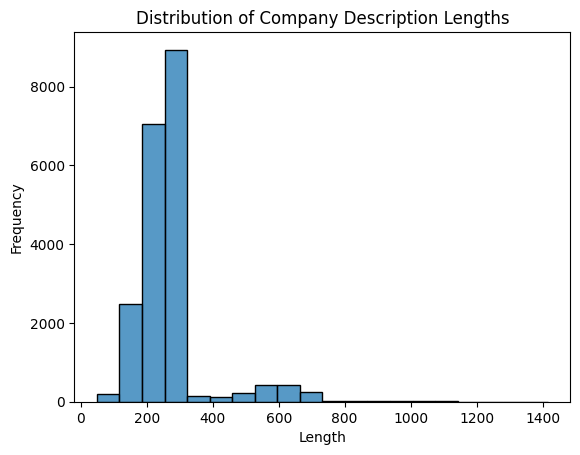

In [17]:
sns.histplot(lengths, bins =20) 
plt.title('Distribution of Company Description Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show() 

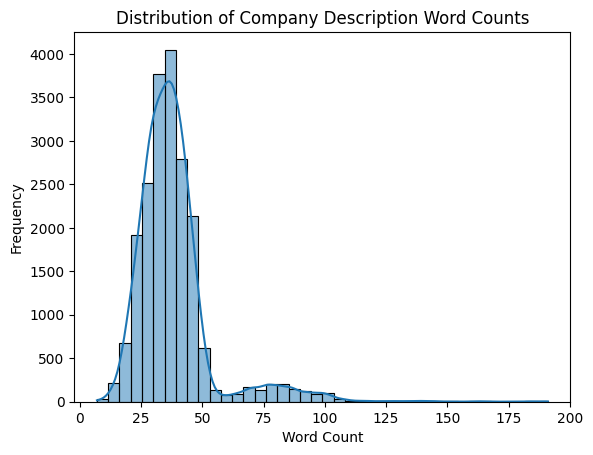

In [18]:
word_counts = [ len(d.split(' '))  for d in data['Company Description']] 
sns.histplot(word_counts, bins =40 , kde = True) 
plt.title('Distribution of Company Description Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show() 